# 1.3 BAL Size Calibration And Regression

This notebook contains the expensive BAL path split out from notebook 1.2.

The BAL builder follows Toni's `eth-bal-analysis` RLP-style block-level BAL semantics as implemented in `src/sim/rpc_bal.py`:

```text
bal_semantics = eip7928_pre_tx_post_indices_v1
include_reads = True
include_system_changes = True
```

The notebook is cache-first:

1. target a deterministic 10-block/day sample,
2. import any already-fetched full-BAL rows from `data/calibration_rpc_blocks_*.csv`,
3. merge the completed light state/access/auth calibration when available,
4. use RPC only for target sample blocks missing from the BAL cache,
5. fit a BAL-size regression and impute daily BAL bytes.


## Setup


In [1]:
import os
import time
from pathlib import Path
import sys

import clickhouse_connect
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from sim.rpc_calibration import calibrate_blocks, sample_blocks_per_day

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")

load_dotenv(PROJECT_ROOT / ".env")
missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
if missing:
    raise RuntimeError("Missing .env values: " + ", ".join(missing))

CLICKHOUSE_RAW_HOST = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")
raw_client = clickhouse_connect.get_client(
    host=CLICKHOUSE_RAW_HOST,
    port=443,
    secure=True,
    username=os.environ["CLICKHOUSE_USER"],
    password=os.environ["CLICKHOUSE_PASSWORD"],
)

ETHNODEOPS_API_KEY = os.environ.get("ETHNODEOPS_API_KEY") or os.environ.get("hoodi_api_key")
ETHNODEOPS_RPC = os.environ.get("ETHNODEOPS_RPC", "https://erigon.mainnet.rpc.ethnodeops.xyz")
ALCHEMY_RPC = os.environ.get("ALCHEMY_RPC")

if ETHNODEOPS_API_KEY:
    RPC_URL = ETHNODEOPS_RPC
    RPC_HEADERS = {"X-API-Key": ETHNODEOPS_API_KEY}
    RPC_PROVIDER_LABEL = "ethnodeops_erigon_mainnet"
elif ALCHEMY_RPC:
    RPC_URL = ALCHEMY_RPC
    RPC_HEADERS = None
    RPC_PROVIDER_LABEL = "alchemy_mainnet"
else:
    raise RuntimeError("Missing ETHNODEOPS_API_KEY, hoodi_api_key, or ALCHEMY_RPC in .env")

print("raw", CLICKHOUSE_RAW_HOST, raw_client.query("SELECT version()").result_rows)
print("rpc_provider", RPC_PROVIDER_LABEL)


raw clickhouse-raw.xatu.ethpandaops.io [('26.2.5.45',)]
rpc_provider ethnodeops_erigon_mainnet


## Parameters

BAL tracing is much slower than the light calibration path. Start small and top up later. The notebook also imports any full-BAL rows accidentally produced by the old combined 1.2 cache.


In [2]:
NETWORK = "mainnet"
START_DATE = "2026-02-01"
END_DATE = "2026-06-01"  # exclusive, matches the panel

N_PLAN_PER_DAY = 500
RUN_BLOCKS_PER_DAY = 10
PREDICT_BLOCKS_PER_DAY = 50
MAX_DAYS = None
SEED = 42

CPSB = 1530
INCLUDE_BAL = True
INCLUDE_READS = True
INCLUDE_SYSTEM_CHANGES = True
BAL_COMPONENT_BYTE_COLUMNS = [
    "bal_storage_writes_rlp_bytes",
    "bal_storage_reads_rlp_bytes",
    "bal_balance_changes_rlp_bytes",
    "bal_nonce_changes_rlp_bytes",
    "bal_code_changes_rlp_bytes",
    "bal_account_shell_rlp_bytes",
]
MAX_WORKERS = 32
FETCH_MISSING_BAL_WITH_RPC = True
CHUNK_SIZE = 50
XATU_CHUNK_SIZE = 20_000

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

PANEL_CSV = DATA_DIR / f"daily_accounting_panel_{START_DATE}_{END_DATE}.csv"
NO_BAL_CALIBRATED_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_no_bal_{START_DATE}_{END_DATE}.csv"
PLAN_CSV = DATA_DIR / f"calibration_sample_plan_{START_DATE}_{END_DATE}_n{N_PLAN_PER_DAY}_seed{SEED}.csv"
XATU_FEATURES_CSV = DATA_DIR / f"calibration_xatu_block_features_{START_DATE}_{END_DATE}.csv"
BAL_RPC_CALIBRATION_CSV = DATA_DIR / f"calibration_rpc_bal_blocks_{START_DATE}_{END_DATE}.csv"
LEGACY_FULL_RPC_CSV = DATA_DIR / f"calibration_rpc_blocks_{START_DATE}_{END_DATE}.csv"
LIGHT_RPC_CALIBRATION_CSV = DATA_DIR / f"calibration_rpc_state_access_auth_blocks_{START_DATE}_{END_DATE}.csv"
BAL_DAILY_RATES_CSV = DATA_DIR / f"calibration_bal_daily_rates_{START_DATE}_{END_DATE}.csv"
BAL_REGRESSION_CSV = DATA_DIR / f"calibration_bal_regression_{START_DATE}_{END_DATE}.csv"
BLOCK_BANDWIDTH_COMPONENTS_CSV = DATA_DIR / f"calibration_block_bandwidth_components_{START_DATE}_{END_DATE}.csv"
BAL_PREDICTION_BLOCK_CSV = DATA_DIR / f"calibration_bal_block_predictions_{START_DATE}_{END_DATE}.csv"
CALIBRATED_WITH_BAL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{START_DATE}_{END_DATE}.csv"

base_panel_path = NO_BAL_CALIBRATED_PANEL_CSV if NO_BAL_CALIBRATED_PANEL_CSV.exists() else PANEL_CSV
if not base_panel_path.exists():
    raise FileNotFoundError(f"Missing {base_panel_path}. Run notebooks/1.1 and preferably 1.2 first.")

panel = pd.read_csv(base_panel_path)
panel["date"] = panel["date"].astype(str)
if "bandwidth_known_bytes_no_bal" not in panel.columns:
    panel["bandwidth_known_bytes_no_bal"] = panel["bandwidth_known_bytes_no_bal_access_auth"]

print("panel days:", len(panel))
print("base panel:", base_panel_path)
print("max workers:", MAX_WORKERS)
print("fetch missing BAL with RPC:", FETCH_MISSING_BAL_WITH_RPC)


panel days: 120
base panel: /Users/william/PycharmProjects/eip-7999-research/data/daily_accounting_panel_calibrated_no_bal_2026-02-01_2026-06-01.csv
max workers: 32
fetch missing BAL with RPC: True


## Sample Plan


In [3]:
if PLAN_CSV.exists():
    plan = pd.read_csv(PLAN_CSV)
    plan["date"] = plan["date"].astype(str)
    print("loaded", PLAN_CSV)
else:
    plan = sample_blocks_per_day(
        panel[["date", "min_block", "max_block"]],
        n_per_day=N_PLAN_PER_DAY,
        seed=SEED,
    )
    plan.to_csv(PLAN_CSV, index=False)
    print("wrote", PLAN_CSV)

run_dates = sorted(plan["date"].unique())
if MAX_DAYS is not None:
    run_dates = run_dates[:MAX_DAYS]

run_targets = plan[
    plan["date"].isin(run_dates) & (plan["sample_rank"] < RUN_BLOCKS_PER_DAY)
].reset_index(drop=True)

prediction_targets = plan[
    plan["date"].isin(run_dates) & (plan["sample_rank"] < PREDICT_BLOCKS_PER_DAY)
].reset_index(drop=True)

print(
    f"plan: {len(plan):,} blocks | BAL RPC targets: {len(run_targets):,} "
    f"({len(run_dates)} days x {RUN_BLOCKS_PER_DAY}/day) | "
    f"Model-B prediction targets: {len(prediction_targets):,} "
    f"({PREDICT_BLOCKS_PER_DAY}/day)"
)

loaded /Users/william/PycharmProjects/eip-7999-research/data/calibration_sample_plan_2026-02-01_2026-06-01_n500_seed42.csv
plan: 60,000 blocks | BAL RPC targets: 1,200 (120 days x 10/day) | Model-B prediction targets: 6,000 (50/day)


## Xatu Block Features


In [4]:
ZERO_WORD = "0x" + "00" * 32

EXPECTED_XATU_FEATURE_COLUMNS = [
    "tx_count_xatu",
    "calldata_bytes_xatu",
    "calldata_zero_bytes_xatu",
    "calldata_nonzero_bytes_xatu",
    "type4_tx_count_xatu",
    "blob_versioned_hash_count_xatu",
    "blob_versioned_hash_bytes_xatu",
    "storage_diff_count",
    "zero_to_nonzero_writes",
    "balance_diff_count",
    "balance_diff_accounts",
    "nonce_diff_count",
]


def query_xatu_features(blocks: list[int]) -> pd.DataFrame:
    params = {"network": NETWORK, "blocks": blocks, "zero_word": ZERO_WORD}
    txs = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS tx_count_xatu,
            toInt64(sum(n_input_bytes)) AS calldata_bytes_xatu,
            toInt64(sum(n_input_zero_bytes)) AS calldata_zero_bytes_xatu,
            toInt64(sum(n_input_nonzero_bytes)) AS calldata_nonzero_bytes_xatu,
            countIf(type = 4) AS type4_tx_count_xatu,
            toInt64(sum(length(blob_hashes))) AS blob_versioned_hash_count_xatu,
            toInt64(32 * sum(length(blob_hashes))) AS blob_versioned_hash_bytes_xatu
        FROM default.execution_transaction FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    storage = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS storage_diff_count,
            countIf(
                lower(from_value) = {zero_word:String}
                AND lower(to_value) != {zero_word:String}
            ) AS zero_to_nonzero_writes
        FROM default.canonical_execution_storage_diffs FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    balance = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS balance_diff_count,
            uniqExact(lower(address)) AS balance_diff_accounts
        FROM default.canonical_execution_balance_diffs FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    nonce = raw_client.query_df(
        '''
        SELECT
            block_number,
            count() AS nonce_diff_count
        FROM default.canonical_execution_nonce_diffs FINAL
        WHERE meta_network_name = {network:String}
          AND block_number IN {blocks:Array(UInt64)}
        GROUP BY block_number
        ''',
        parameters=params,
    )
    out = pd.DataFrame({"block_number": blocks})
    for frame in [txs, storage, balance, nonce]:
        if not frame.empty:
            out = out.merge(frame, on="block_number", how="left")
    return out


if XATU_FEATURES_CSV.exists():
    xatu_features = pd.read_csv(XATU_FEATURES_CSV)
else:
    xatu_features = pd.DataFrame(columns=["block_number"])

missing_schema = [col for col in EXPECTED_XATU_FEATURE_COLUMNS if col not in xatu_features.columns]
if missing_schema and len(xatu_features):
    print("cached Xatu feature file is missing columns; refreshing target rows:", missing_schema)
    xatu_features = pd.DataFrame(columns=["block_number"])

have = set(xatu_features["block_number"].astype("int64")) if len(xatu_features) else set()
need = [int(b) for b in prediction_targets["block_number"] if int(b) not in have]
print(f"xatu features cached: {len(have):,} | missing for prediction targets: {len(need):,}")

for start in range(0, len(need), XATU_CHUNK_SIZE):
    chunk = need[start : start + XATU_CHUNK_SIZE]
    fetched = query_xatu_features(chunk)
    xatu_features = pd.concat([xatu_features, fetched], ignore_index=True)
    xatu_features = xatu_features.drop_duplicates("block_number")
    xatu_features.to_csv(XATU_FEATURES_CSV, index=False)
    print(f"  +{len(chunk):,} -> {len(xatu_features):,} rows cached")

for col in EXPECTED_XATU_FEATURE_COLUMNS:
    if col not in xatu_features.columns:
        xatu_features[col] = 0
fill_cols = [c for c in xatu_features.columns if c != "block_number"]
xatu_features[fill_cols] = xatu_features[fill_cols].fillna(0)
xatu_features["block_number"] = xatu_features["block_number"].astype("int64")
xatu_features.tail(3)


xatu features cached: 6,000 | missing for prediction targets: 0


,block_number,tx_count_xatu,calldata_bytes_xatu,calldata_zero_bytes_xatu,calldata_nonzero_bytes_xatu,type4_tx_count_xatu,blob_versioned_hash_count_xatu,blob_versioned_hash_bytes_xatu,storage_diff_count,zero_to_nonzero_writes,balance_diff_count,balance_diff_accounts,nonce_diff_count
5997,25212031,795.0000,"34,372.0000","23,265.0000","11,107.0000",3.0000,1.0000,32.0000,301.0000,61.0000,"2,339.0000","1,516.0000",800.0000
5998,25216111,289.0000,"280,977.0000","194,126.0000","86,851.0000",5.0000,1.0000,32.0000,"1,175.0000",316.0000,"1,100.0000",743.0000,332.0000
5999,25217280,351.0000,"121,603.0000","76,073.0000","45,530.0000",4.0000,6.0000,192.0000,828.0000,124.0000,"1,057.0000",628.0000,356.0000


## BAL RPC Calibration Loop

This loop writes only rows with `bal_rlp_bytes`. It first imports any compatible full-BAL rows from the old combined calibration cache, then fetches missing target blocks.


In [5]:
if BAL_RPC_CALIBRATION_CSV.exists():
    bal_cal = pd.read_csv(BAL_RPC_CALIBRATION_CSV)
else:
    bal_cal = pd.DataFrame(columns=["block_number"])

if LEGACY_FULL_RPC_CSV.exists():
    legacy = pd.read_csv(LEGACY_FULL_RPC_CSV)
    if "bal_rlp_bytes" in legacy.columns:
        before = len(bal_cal)
        bal_cal = pd.concat([bal_cal, legacy], ignore_index=True)
        bal_cal = bal_cal.drop_duplicates("block_number")
        bal_cal.to_csv(BAL_RPC_CALIBRATION_CSV, index=False)
        print(f"imported legacy BAL rows: {len(bal_cal) - before:,}")

for col in BAL_COMPONENT_BYTE_COLUMNS:
    if col not in bal_cal.columns:
        bal_cal[col] = np.nan
component_complete = bal_cal[BAL_COMPONENT_BYTE_COLUMNS].notna().all(axis=1)
done = set(bal_cal.loc[component_complete, "block_number"].astype("int64")) if len(bal_cal) else set()
target_blocks = set(run_targets["block_number"].astype("int64"))
cached_target = len(target_blocks & done)
todo = [int(b) for b in run_targets["block_number"] if int(b) not in done]
print(f"BAL target blocks: {len(run_targets):,} | component-complete cached targets: {cached_target:,} | missing: {len(todo):,}")

all_failed: list[int] = []
started = time.time()
if FETCH_MISSING_BAL_WITH_RPC:
    for start in range(0, len(todo), CHUNK_SIZE):
        chunk = todo[start : start + CHUNK_SIZE]
        chunk_started = time.time()
        frame, failed = calibrate_blocks(
            RPC_URL,
            chunk,
            cpsb=CPSB,
            include_reads=INCLUDE_READS,
            include_system_changes=INCLUDE_SYSTEM_CHANGES,
            include_bal=INCLUDE_BAL,
            rpc_headers=RPC_HEADERS,
            max_workers=MAX_WORKERS,
            on_error="skip",
        )
        all_failed.extend(failed)
        if not frame.empty:
            refreshed_blocks = set(frame["block_number"].astype("int64"))
            bal_cal = pd.concat([
                bal_cal.loc[~bal_cal["block_number"].astype("int64").isin(refreshed_blocks)],
                frame,
            ], ignore_index=True, sort=False)
            bal_cal.to_csv(BAL_RPC_CALIBRATION_CSV, index=False)
        elapsed = time.time() - chunk_started
        done_now = start + len(chunk)
        rate = len(chunk) / max(elapsed, 1e-9)
        remaining = (len(todo) - done_now) / max(rate, 1e-9)
        print(
            f"  chunk {start}-{start + len(chunk)}: {elapsed:,.0f}s "
            f"({rate:.2f} blocks/s) | cached {len(bal_cal):,} | "
            f"failed {len(failed)} | ETA {remaining / 60:,.0f} min"
        )
else:
    print("FETCH_MISSING_BAL_WITH_RPC=False, using cached BAL rows only")

print(f"total elapsed {(time.time() - started) / 60:,.1f} min | failed blocks: {len(all_failed)}")
if all_failed:
    print("failed (will retry next run):", all_failed[:20], "...")

bal_cal["block_number"] = bal_cal["block_number"].astype("int64")
cal = run_targets.merge(bal_cal, on="block_number", how="inner")
missing_component_rows = cal[BAL_COMPONENT_BYTE_COLUMNS].isna().any(axis=1)
if missing_component_rows.any():
    raise ValueError(f"{int(missing_component_rows.sum())} target blocks still lack exact BAL component bytes")

if LIGHT_RPC_CALIBRATION_CSV.exists():
    light_cal = pd.read_csv(LIGHT_RPC_CALIBRATION_CSV)
    light_cal["block_number"] = light_cal["block_number"].astype("int64")
    light_cols = [
        "block_number",
        "tx_access_list_bytes",
        "tx_access_list_gas_7981",
        "authorization_tuple_8131_bytes",
        "authorization_tuple_rlp_bytes",
        "rpc_state_gas_used",
        "rpc_new_delegation_indicators",
    ]
    light_cols = [col for col in light_cols if col in light_cal.columns]
    cal = cal.merge(
        light_cal[light_cols].drop_duplicates("block_number"),
        on="block_number",
        how="left",
        suffixes=("", "_light"),
    )
    for col in [c for c in light_cols if c != "block_number"]:
        light_col = f"{col}_light"
        if light_col in cal.columns:
            cal[col] = cal[col].fillna(cal[light_col])
            cal = cal.drop(columns=[light_col])
    print("merged light state/access/auth calibration", LIGHT_RPC_CALIBRATION_CSV)
else:
    print("missing light calibration file", LIGHT_RPC_CALIBRATION_CSV)

cal = (
    cal.merge(xatu_features, on="block_number", how="left")
    .sort_values("block_number")
    .reset_index(drop=True)
)

# Xatu features are preferred for the transferable regression, but RPC-derived
# values keep otherwise usable rows when Xatu coverage is missing.
fallbacks = {
    "tx_count_xatu": "tx_count",
    "calldata_bytes_xatu": "calldata_bytes_rpc",
    "zero_to_nonzero_writes": "rpc_new_storage_slots",
    "storage_diff_count": "rpc_new_storage_slots",
    "balance_diff_count": "bal_balance_changes",
    "nonce_diff_count": "bal_nonce_changes",
    "type4_tx_count_xatu": "type4_tx_count",
    "blob_versioned_hash_bytes_xatu": "blob_versioned_hash_bytes",
    "blob_versioned_hash_count_xatu": "blob_versioned_hash_count",
}
for target, source in fallbacks.items():
    if target not in cal.columns:
        cal[target] = pd.NA
    if source in cal.columns:
        cal[target] = cal[target].fillna(cal[source])

feature_cols = [
    "tx_count_xatu",
    "calldata_bytes_xatu",
    "zero_to_nonzero_writes",
    "storage_diff_count",
    "balance_diff_count",
    "nonce_diff_count",
]
cal[feature_cols] = cal[feature_cols].apply(pd.to_numeric, errors="coerce")

print("joined BAL calibration rows:", len(cal))
print("sample days covered:", cal["date"].nunique() if len(cal) else 0)
if len(cal):
    print("rows with complete regression features:", int(cal[feature_cols + ["bal_rlp_bytes"]].notna().all(axis=1).sum()))
cal[["date", "block_number", "bal_rlp_bytes", "bal_storage_reads", "calldata_bytes_xatu"]].head(3)


imported legacy BAL rows: 0
BAL target blocks: 1,200 | component-complete cached targets: 1,200 | missing: 0
total elapsed 0.0 min | failed blocks: 0
merged light state/access/auth calibration /Users/william/PycharmProjects/eip-7999-research/data/calibration_rpc_state_access_auth_blocks_2026-02-01_2026-06-01.csv
joined BAL calibration rows: 1200
sample days covered: 120
rows with complete regression features: 1200


,date,block_number,bal_rlp_bytes,bal_storage_reads,calldata_bytes_xatu
0,2026-02-01,24358339,"97,880.0000",948.0000,"83,827.0000"
1,2026-02-01,24359237,"116,648.0000",819.0000,"72,898.0000"
2,2026-02-01,24360149,"172,141.0000",962.0000,"82,401.0000"


## Block-Level Bandwidth Components

This is the most useful table for replay and tail checks: one row is one sampled block. Daily rates below are only an aggregation of this table.

The component definitions are:

```text
bandwidth_bytes = calldata_bytes
                + access_list_bytes
                + authorization_tuple_8131_bytes
                + blob_versioned_hash_bytes
                + BAL_RLP_bytes
```

For this notebook:

- `calldata_bytes` comes from Xatu `execution_transaction`, with RPC calldata as a fallback for cache holes.
- `access_list_bytes` comes from RPC block transactions and is `20 * address_count + 32 * storage_key_count`.
- `authorization_tuple_8131_bytes` uses the fixed EIP-8131-style `108 bytes * tuple_count` bandwidth accounting.
- `blob_versioned_hash_bytes` is `32 bytes * blob_versioned_hash_count`.
- `bal_rlp_bytes` is the expensive EIP-7928-style RLP BAL estimate with reads and system changes included.

This table is intentionally block-level because limit hits and fee updates are block-level phenomena. The daily table smooths these rows for long-window reporting only.

In [6]:
def numeric_series(frame: pd.DataFrame, column: str, default: int = 0) -> pd.Series:
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors="coerce")
    return pd.Series(default, index=frame.index, dtype="float64")

calldata_xatu = numeric_series(cal, "calldata_bytes_xatu")
calldata_rpc = numeric_series(cal, "calldata_bytes_rpc")
blob_xatu = numeric_series(cal, "blob_versioned_hash_bytes_xatu")
blob_rpc = numeric_series(cal, "blob_versioned_hash_bytes")

block_bandwidth_components = cal[["date", "block_number"]].copy()
block_bandwidth_components["calldata_bytes"] = calldata_xatu.fillna(calldata_rpc).fillna(0)
block_bandwidth_components["access_list_bytes"] = numeric_series(cal, "tx_access_list_bytes").fillna(0)
block_bandwidth_components["authorization_tuple_8131_bytes"] = numeric_series(
    cal,
    "authorization_tuple_8131_bytes",
).fillna(0)
block_bandwidth_components["blob_versioned_hash_bytes"] = blob_xatu.fillna(blob_rpc).fillna(0)
block_bandwidth_components["bal_rlp_bytes"] = numeric_series(cal, "bal_rlp_bytes").fillna(0)

component_cols = [
    "calldata_bytes",
    "access_list_bytes",
    "authorization_tuple_8131_bytes",
    "blob_versioned_hash_bytes",
    "bal_rlp_bytes",
]
block_bandwidth_components["bandwidth_bytes_no_bal"] = block_bandwidth_components[
    [
        "calldata_bytes",
        "access_list_bytes",
        "authorization_tuple_8131_bytes",
        "blob_versioned_hash_bytes",
    ]
].sum(axis=1)
block_bandwidth_components["bandwidth_bytes_with_bal"] = block_bandwidth_components[
    component_cols
].sum(axis=1)
block_bandwidth_components["bandwidth_gas_16_with_bal"] = (
    16 * block_bandwidth_components["bandwidth_bytes_with_bal"]
)

block_bandwidth_components.to_csv(BLOCK_BANDWIDTH_COMPONENTS_CSV, index=False)
print(BLOCK_BANDWIDTH_COMPONENTS_CSV)

summary_cols = component_cols + ["bandwidth_bytes_with_bal", "bandwidth_gas_16_with_bal"]
display(block_bandwidth_components[summary_cols].describe(percentiles=[0.1, 0.5, 0.9, 0.95, 0.99]))
display(block_bandwidth_components.head(10))

/Users/william/PycharmProjects/eip-7999-research/data/calibration_block_bandwidth_components_2026-02-01_2026-06-01.csv


,calldata_bytes,access_list_bytes,authorization_tuple_8131_bytes,blob_versioned_hash_bytes,bal_rlp_bytes,bandwidth_bytes_with_bal,bandwidth_gas_16_with_bal
count,"1,200.0000","1,200.0000","1,200.0000","1,200.0000","1,200.0000","1,200.0000","1,200.0000"
mean,"127,278.2858","5,843.6500","1,196.9100",111.9200,"134,086.5350","268,517.3008","4,296,276.8133"
std,"75,365.2687","8,517.7683","2,247.8794",122.2460,"56,719.3474","120,054.9107","1,920,878.5718"
min,"2,472.0000",0.0000,0.0000,0.0000,"7,450.0000","9,922.0000","158,752.0000"
10%,"46,291.2000",0.0000,0.0000,0.0000,"62,171.6000","117,319.4000","1,877,110.4000"
50%,"111,701.0000","3,716.0000",432.0000,64.0000,"128,825.0000","255,843.5000","4,093,496.0000"
90%,"223,254.8000","12,593.2000","2,926.8000",288.0000,"210,291.5000","431,693.8000","6,907,100.8000"
95%,"268,932.3500","18,446.0000","4,752.0000",352.0000,"236,009.2500","492,064.2500","7,873,028.0000"
99%,"348,167.2600","39,900.6000","11,016.0000",480.0000,"281,863.6200","581,452.7700","9,303,244.3200"
max,"706,430.0000","138,532.0000","36,504.0000",672.0000,"405,525.0000","855,226.0000","13,683,616.0000"


,date,block_number,calldata_bytes,access_list_bytes,authorization_tuple_8131_bytes,blob_versioned_hash_bytes,bal_rlp_bytes,bandwidth_bytes_no_bal,bandwidth_bytes_with_bal,bandwidth_gas_16_with_bal
0,2026-02-01,24358339,"83,827.0000","8,780.0000",216.0000,160.0000,"97,880.0000","92,983.0000","190,863.0000","3,053,808.0000"
1,2026-02-01,24359237,"72,898.0000","7,516.0000",108.0000,0.0000,"116,648.0000","80,522.0000","197,170.0000","3,154,720.0000"
2,2026-02-01,24360149,"82,401.0000","5,540.0000",324.0000,32.0000,"172,141.0000","88,297.0000","260,438.0000","4,167,008.0000"
3,2026-02-01,24360293,"123,026.0000","33,616.0000",216.0000,32.0000,"249,205.0000","156,890.0000","406,095.0000","6,497,520.0000"
4,2026-02-01,24362542,"190,336.0000","2,300.0000",432.0000,32.0000,"129,701.0000","193,100.0000","322,801.0000","5,164,816.0000"
5,2026-02-01,24362603,"86,066.0000","4,408.0000",108.0000,256.0000,"129,955.0000","90,838.0000","220,793.0000","3,532,688.0000"
6,2026-02-01,24363763,"89,825.0000","22,072.0000",108.0000,224.0000,"178,108.0000","112,229.0000","290,337.0000","4,645,392.0000"
7,2026-02-01,24363863,"152,230.0000","5,932.0000","2,592.0000",288.0000,"175,199.0000","161,042.0000","336,241.0000","5,379,856.0000"
8,2026-02-01,24364279,"88,889.0000","13,184.0000",324.0000,0.0000,"151,609.0000","102,397.0000","254,006.0000","4,064,096.0000"
9,2026-02-01,24365033,"171,953.0000","15,228.0000",216.0000,160.0000,"118,042.0000","187,557.0000","305,599.0000","4,889,584.0000"


## Daily BAL Rates

This section compresses the block-level calibration table into one rate per day. Use it for long-window scale checks, not for replay. The per-block table above is the safer input for block-level limit and fee-path analysis.

In [7]:
daily_bal_rates = cal.groupby("date", as_index=False).agg(
    sampled_blocks=("block_number", "count"),
    bal_rlp_bytes_per_block=("bal_rlp_bytes", "mean"),
    bal_storage_reads_per_block=("bal_storage_reads", "mean"),
    bal_storage_write_slots_per_block=("bal_storage_write_slots", "mean"),
    bal_accounts_per_block=("bal_accounts", "mean"),
)
daily_bal_rates.to_csv(BAL_DAILY_RATES_CSV, index=False)
print(BAL_DAILY_RATES_CSV)
print(daily_bal_rates.head(6).to_string(index=False))


/Users/william/PycharmProjects/eip-7999-research/data/calibration_bal_daily_rates_2026-02-01_2026-06-01.csv
      date  sampled_blocks  bal_rlp_bytes_per_block  bal_storage_reads_per_block  bal_storage_write_slots_per_block  bal_accounts_per_block
2026-02-01              10             151,848.8000                   1,243.7000                           876.2000                955.5000
2026-02-02              10             134,127.3000                     975.3000                           822.2000                863.9000
2026-02-03              10             152,727.4000                   1,187.5000                           890.0000                980.7000
2026-02-04              10             156,104.3000                   1,245.7000                           879.1000              1,009.7000
2026-02-05              10             126,169.5000                   1,093.6000                           760.0000                694.9000
2026-02-06              10             138,377.4000 

## BAL Regression

The expensive quantity is `bal_rlp_bytes`. We fit one OLS prediction model so that blocks without full BAL tracing can receive an estimated BAL size from cheaper Xatu transaction and state-diff features:

```text
BAL_i = beta_0
      + beta_1 * tx_count_i
      + beta_2 * zero_to_nonzero_writes_i
      + beta_3 * calldata_bytes_i
      + beta_4 * storage_diff_count_i
      + beta_5 * balance_diff_count_i
      + beta_6 * nonce_diff_count_i
      + epsilon_i
```

The split is time-based: the first 80% of days train the model, and the last 20% are held out. The coefficients are for prediction, not causal interpretation.

train blocks 960 (96 days) | test blocks 240
/Users/william/PycharmProjects/eip-7999-research/data/calibration_bal_regression_2026-02-01_2026-06-01.csv


,model,features,train_blocks,test_blocks,r2_train,r2_test
0,selected_xatu_state_diff,6,960,240,0.9460,0.9191


,model,feature,coef
0,selected_xatu_state_diff,intercept,"5,754.3907"
1,selected_xatu_state_diff,tx_count_xatu,-63.6530
2,selected_xatu_state_diff,zero_to_nonzero_writes,-17.8659
3,selected_xatu_state_diff,calldata_bytes_xatu,0.0580
4,selected_xatu_state_diff,storage_diff_count,107.1196
5,selected_xatu_state_diff,balance_diff_count,37.4606
6,selected_xatu_state_diff,nonce_diff_count,44.2205


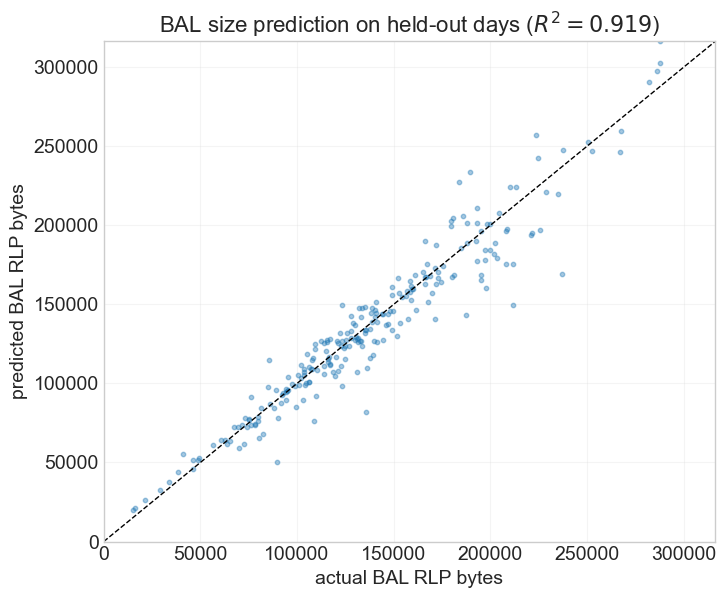

In [8]:
MODEL_NAME = "selected_xatu_state_diff"
FEATURES = [
    "tx_count_xatu", "zero_to_nonzero_writes", "calldata_bytes_xatu",
    "storage_diff_count", "balance_diff_count", "nonce_diff_count",
]
TARGET = "bal_rlp_bytes"

reg_frame = cal.dropna(subset=FEATURES + [TARGET]).copy()
dates_sorted = sorted(reg_frame["date"].unique())
split_at = max(1, int(len(dates_sorted) * 0.8))
train_dates = set(dates_sorted[:split_at])
train = reg_frame[reg_frame["date"].isin(train_dates)]
test = reg_frame[~reg_frame["date"].isin(train_dates)]
print(f"train blocks {len(train):,} ({len(train_dates)} days) | test blocks {len(test):,}")


def fit_ols(frame, features, target):
    X = np.column_stack([np.ones(len(frame))] + [frame[f].to_numpy(float) for f in features])
    y = frame[target].to_numpy(float)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coef


def predict_ols(frame, features, coef):
    X = np.column_stack([np.ones(len(frame))] + [frame[f].to_numpy(float) for f in features])
    return X @ coef


def r_squared(y_true, y_pred):
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return 1.0 - ss_res / ss_tot if ss_tot else float("nan")

coef = fit_ols(train, FEATURES, TARGET)
coefs = {MODEL_NAME: (FEATURES, coef)}
train_pred = predict_ols(train, FEATURES, coef)
test_pred = predict_ols(test, FEATURES, coef) if len(test) else np.array([])
r2_train = r_squared(train[TARGET].to_numpy(float), train_pred)
r2_test = r_squared(test[TARGET].to_numpy(float), test_pred) if len(test) else float("nan")

model_fit_table = pd.DataFrame([{
    "model": MODEL_NAME,
    "features": len(FEATURES),
    "train_blocks": len(train),
    "test_blocks": len(test),
    "r2_train": r2_train,
    "r2_test": r2_test,
}])
coefficient_table = pd.DataFrame([
    {"model": MODEL_NAME, "feature": feature, "coef": value}
    for feature, value in zip(["intercept"] + FEATURES, coef)
])
regression_table = pd.concat(
    [
        model_fit_table.assign(row_type="fit"),
        coefficient_table.assign(row_type="coefficient"),
    ],
    ignore_index=True,
    sort=False,
)
regression_table.to_csv(BAL_REGRESSION_CSV, index=False)
print(BAL_REGRESSION_CSV)
display(model_fit_table)
display(coefficient_table)

if len(test):
    fig, ax = plt.subplots(figsize=(7.5, 6.2))
    max_seen = max(float(test[TARGET].max()), float(test_pred.max()))
    ax.scatter(test[TARGET], test_pred, s=10, alpha=0.4)
    ax.plot([0, max_seen], [0, max_seen], color="black", linewidth=1, linestyle="--")
    ax.set_xlim(0, max_seen)
    ax.set_ylim(0, max_seen)
    ax.set_xlabel("actual BAL RLP bytes")
    ax.set_ylabel("predicted BAL RLP bytes")
    ax.set_title(f"BAL size prediction on held-out days ($R^2={r2_test:.3f}$)")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f"calibration_bal_regression_{START_DATE}_{END_DATE}.png", dpi=160)
    plt.show()

## Apply The BAL Size Regression To The Daily Panel

The daily accounting panel is aggregated, but the BAL estimator is block-level. This section applies the selected regression to a wider per-block Xatu sample (`PREDICT_BLOCKS_PER_DAY`, currently 50/day), then aggregates by day.

For each day we use:

```text
10 observed BAL blocks from RPC tracing
40 regression-predicted BAL blocks
```

More precisely, each sampled block gets:

```text
bal_rlp_bytes_calibrated = observed_BAL_if_available_else_regression_prediction
```

Then the daily BAL rate is the mean of those calibrated sampled blocks. The final plot is a stacked bar chart of total bandwidth bytes across the 50 sampled blocks for each day.

/Users/william/PycharmProjects/eip-7999-research/data/calibration_bal_block_predictions_2026-02-01_2026-06-01.csv
observed+selected_xatu_state_diff vs sampled daily BAL: corr 0.483 | mean ratio 1.006
/Users/william/PycharmProjects/eip-7999-research/data/daily_accounting_panel_calibrated_with_bal_2026-02-01_2026-06-01.csv
bandwidth_calldata_bytes                   108,037,091,368.0000
bandwidth_access_list_bytes                  4,941,804,556.5600
bandwidth_authorization_tuple_8131_bytes     1,131,316,176.2400
bandwidth_blob_hash_bytes                       99,184,640.0000
bandwidth_bal_rlp_bytes                    113,910,862,283.8748
bandwidth_bytes_calibrated_with_bal        228,120,259,024.6747


,date,prediction_blocks,observed_bal_blocks,predicted_bal_blocks,sample50_bandwidth_calldata_bytes,sample50_bandwidth_access_list_bytes,sample50_bandwidth_authorization_tuple_8131_bytes,sample50_bandwidth_blob_hash_bytes,sample50_bandwidth_bal_rlp_bytes,sample50_bandwidth_bytes_calibrated,cal_bal_rlp_bytes_per_block_pred,cal_bal_rlp_bytes_per_block_regression_only,cal_bal_rlp_bytes_per_block_observed,cal_bal_rlp_bytes_sample_sum
0,2026-02-01,50,10,40,"4,852,863.0000","423,472.0000","18,468.0000","7,872.0000","6,735,608.6079","12,038,283.6079","134,712.1722","133,894.5609","151,848.8000","6,735,608.6079"
1,2026-02-02,50,10,40,"5,654,323.0000","494,388.0000","6,264.0000","7,712.0000","7,371,671.6680","13,534,358.6680","147,433.4334","148,442.9138","134,127.3000","7,371,671.6680"
2,2026-02-03,50,10,40,"5,519,860.0000","428,824.0000","5,832.0000","8,320.0000","7,098,913.3899","13,061,749.3899","141,978.2678","141,602.0016","152,727.4000","7,098,913.3899"
3,2026-02-04,50,10,40,"6,373,050.0000","382,252.0000","11,556.0000","8,256.0000","6,964,104.5224","13,739,218.5224","139,282.0904","139,035.9158","156,104.3000","6,964,104.5224"
4,2026-02-05,50,10,40,"5,132,852.0000","488,656.0000","4,752.0000","9,600.0000","6,313,366.4107","11,949,226.4107","126,267.3282","126,187.0014","126,169.5000","6,313,366.4107"
5,2026-02-06,50,10,40,"5,645,022.0000","568,452.0000","5,076.0000","10,272.0000","6,932,797.3414","13,161,619.3414","138,655.9468","138,396.1089","138,377.4000","6,932,797.3414"
6,2026-02-07,50,10,40,"5,648,238.0000","372,848.0000","5,292.0000","8,704.0000","6,919,630.3244","12,954,712.3244","138,392.6065","139,823.1269","132,374.6000","6,919,630.3244"
7,2026-02-08,50,10,40,"7,100,680.0000","393,928.0000","31,860.0000","8,640.0000","6,954,760.5758","14,489,868.5758","139,095.2115","139,059.7161","138,049.7000","6,954,760.5758"
8,2026-02-09,50,10,40,"5,170,362.0000","437,196.0000","11,556.0000","8,448.0000","6,357,778.2181","11,985,340.2181","127,155.5644","126,977.6756","116,445.9000","6,357,778.2181"
9,2026-02-10,50,10,40,"5,688,422.0000","294,784.0000","13,068.0000","7,648.0000","6,054,466.4703","12,058,388.4703","121,089.3294","121,377.2826","121,553.5000","6,054,466.4703"


,date,block_count,prediction_blocks,observed_bal_blocks,predicted_bal_blocks,bandwidth_calldata_bytes,bandwidth_access_list_bytes,bandwidth_authorization_tuple_8131_bytes,bandwidth_blob_hash_bytes,bandwidth_bal_rlp_bytes,bandwidth_bytes_calibrated_with_bal
0,2026-02-01,7161,50,10,40,748121362,"60,649,659.8400","2,644,986.9600",1067072,"964,673,864.8302","1,777,156,945.6302"
1,2026-02-02,7160,50,10,40,791365953,"70,796,361.6000","897,004.8000",1111776,"1,055,623,382.8567","1,919,794,478.2567"
2,2026-02-03,7149,50,10,40,786407615,"61,313,255.5200","833,859.3600",1129824,"1,015,002,636.4825","1,864,687,190.3625"
3,2026-02-04,7152,50,10,40,810410876,"54,677,326.0800","1,652,970.2400",1115360,"996,145,510.8843","1,864,002,043.2043"
4,2026-02-05,7150,50,10,40,823132195,"69,877,808.0000","679,536.0000",1427072,"902,811,396.7247","1,797,928,007.7247"
5,2026-02-06,7158,50,10,40,819646113,"81,379,588.3200","726,680.1600",1198656,"992,499,267.3907","1,895,450,304.8707"
6,2026-02-07,7162,50,10,40,753329767,"53,406,747.5200","758,026.0800",1056288,"991,167,847.6684","1,799,718,676.2684"
7,2026-02-08,7109,50,10,40,822964531,"56,008,683.0400","4,529,854.8000",1018912,"988,827,858.6624","1,873,349,839.5024"
8,2026-02-09,7160,50,10,40,829276106,"62,606,467.2000","1,654,819.2000",1054144,"910,433,840.8273","1,805,025,377.2273"
9,2026-02-10,7156,50,10,40,822488130,"42,189,486.0800","1,870,292.1600",1010880,"866,515,241.2297","1,734,074,029.4697"


/Users/william/PycharmProjects/eip-7999-research/plots/daily_accounting_bandwidth_components_calibrated_2026-02-01_2026-06-01.png


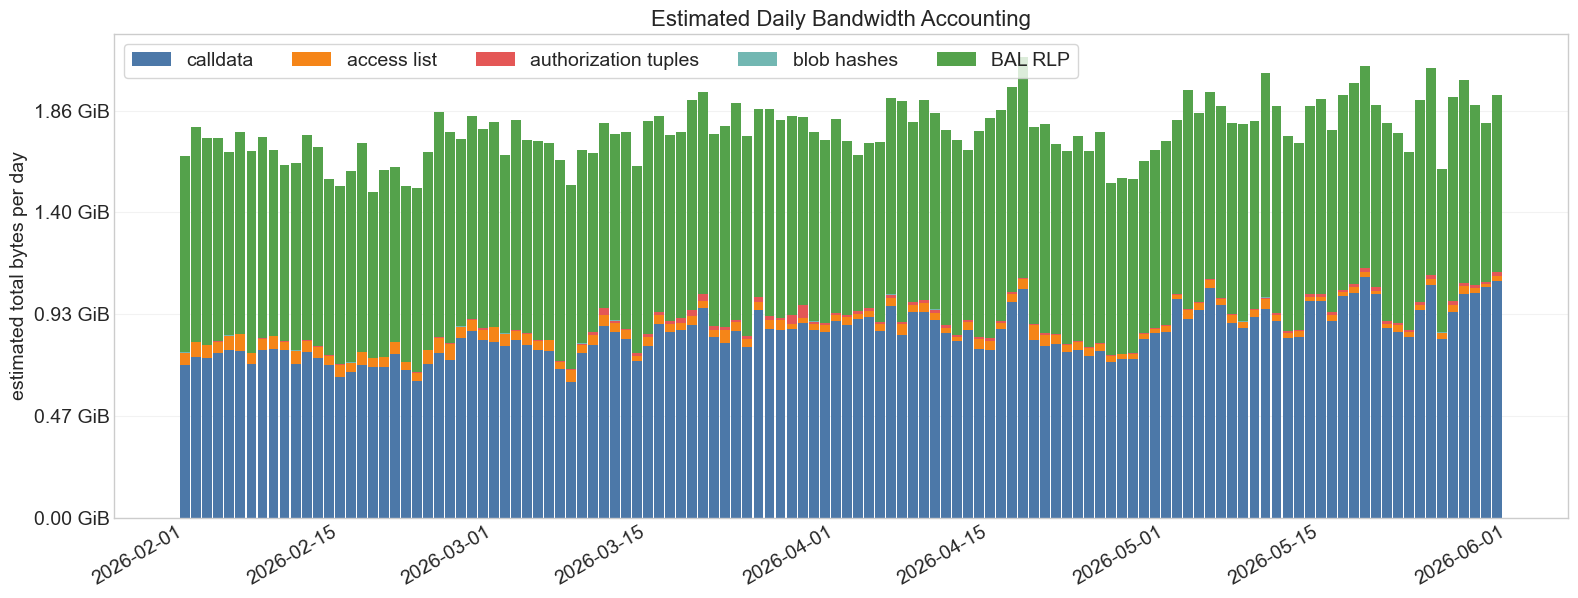

In [9]:
APPLY_MODEL = MODEL_NAME
apply_features, apply_coef = coefs[APPLY_MODEL]

prediction_features = prediction_targets.merge(
    xatu_features,
    on="block_number",
    how="left",
)
for col in FEATURES:
    if col not in prediction_features.columns:
        prediction_features[col] = 0
    prediction_features[col] = pd.to_numeric(prediction_features[col], errors="coerce").fillna(0)

prediction_features["bal_rlp_bytes_pred"] = predict_ols(
    prediction_features,
    apply_features,
    apply_coef,
).clip(min=0)

prediction_features = prediction_features.merge(
    cal[["block_number", "bal_rlp_bytes"]].rename(columns={"bal_rlp_bytes": "bal_rlp_bytes_observed"}),
    on="block_number",
    how="left",
)
prediction_features["bal_source"] = np.where(
    prediction_features["bal_rlp_bytes_observed"].notna(),
    "observed_rpc",
    "regression_predicted",
)
prediction_features["bal_rlp_bytes_calibrated"] = prediction_features[
    "bal_rlp_bytes_observed"
].fillna(prediction_features["bal_rlp_bytes_pred"])

# Fill the other bandwidth components for the same 50 sampled blocks.
light_component_cols = [
    "block_number",
    "tx_access_list_bytes",
    "authorization_tuple_8131_bytes",
]
if LIGHT_RPC_CALIBRATION_CSV.exists():
    light_components = pd.read_csv(LIGHT_RPC_CALIBRATION_CSV)
    light_components["block_number"] = light_components["block_number"].astype("int64")
    light_component_cols = [col for col in light_component_cols if col in light_components.columns]
    prediction_features = prediction_features.merge(
        light_components[light_component_cols].drop_duplicates("block_number"),
        on="block_number",
        how="left",
    )
else:
    print("missing light calibration file", LIGHT_RPC_CALIBRATION_CSV)

component_defaults = {
    "calldata_bytes_xatu": 0,
    "tx_access_list_bytes": 0,
    "authorization_tuple_8131_bytes": 0,
    "blob_versioned_hash_bytes_xatu": 0,
    "bal_rlp_bytes_calibrated": 0,
}
for col, default in component_defaults.items():
    if col not in prediction_features.columns:
        prediction_features[col] = default
    prediction_features[col] = pd.to_numeric(prediction_features[col], errors="coerce").fillna(default)

prediction_features["bandwidth_calldata_bytes"] = prediction_features["calldata_bytes_xatu"]
prediction_features["bandwidth_access_list_bytes"] = prediction_features["tx_access_list_bytes"]
prediction_features["bandwidth_authorization_tuple_8131_bytes"] = prediction_features[
    "authorization_tuple_8131_bytes"
]
prediction_features["bandwidth_blob_hash_bytes"] = prediction_features["blob_versioned_hash_bytes_xatu"]
prediction_features["bandwidth_bal_rlp_bytes"] = prediction_features["bal_rlp_bytes_calibrated"]

bandwidth_component_cols = [
    "bandwidth_calldata_bytes",
    "bandwidth_access_list_bytes",
    "bandwidth_authorization_tuple_8131_bytes",
    "bandwidth_blob_hash_bytes",
    "bandwidth_bal_rlp_bytes",
]
prediction_features["bandwidth_bytes_calibrated"] = prediction_features[
    bandwidth_component_cols
].sum(axis=1)
prediction_features.to_csv(BAL_PREDICTION_BLOCK_CSV, index=False)
print(BAL_PREDICTION_BLOCK_CSV)

sample50_daily = prediction_features.groupby("date", as_index=False).agg(
    prediction_blocks=("block_number", "count"),
    observed_bal_blocks=("bal_rlp_bytes_observed", lambda s: int(s.notna().sum())),
    predicted_bal_blocks=("bal_source", lambda s: int((s == "regression_predicted").sum())),
    sample50_bandwidth_calldata_bytes=("bandwidth_calldata_bytes", "sum"),
    sample50_bandwidth_access_list_bytes=("bandwidth_access_list_bytes", "sum"),
    sample50_bandwidth_authorization_tuple_8131_bytes=("bandwidth_authorization_tuple_8131_bytes", "sum"),
    sample50_bandwidth_blob_hash_bytes=("bandwidth_blob_hash_bytes", "sum"),
    sample50_bandwidth_bal_rlp_bytes=("bandwidth_bal_rlp_bytes", "sum"),
    sample50_bandwidth_bytes_calibrated=("bandwidth_bytes_calibrated", "sum"),
    cal_bal_rlp_bytes_per_block_pred=("bal_rlp_bytes_calibrated", "mean"),
    cal_bal_rlp_bytes_per_block_regression_only=("bal_rlp_bytes_pred", "mean"),
    cal_bal_rlp_bytes_per_block_observed=("bal_rlp_bytes_observed", "mean"),
)
sample50_daily["cal_bal_rlp_bytes_sample_sum"] = sample50_daily[
    "sample50_bandwidth_bal_rlp_bytes"
]

panel_bal = panel.copy()
panel_bal = panel_bal.merge(sample50_daily, on="date", how="left")
panel_bal = panel_bal.merge(
    daily_bal_rates[["date", "sampled_blocks", "bal_rlp_bytes_per_block"]].rename(
        columns={
            "sampled_blocks": "bal_rpc_sampled_blocks",
            "bal_rlp_bytes_per_block": "cal_bal_rlp_bytes_per_block_sampled",
        }
    ),
    on="date",
    how="left",
)
panel_bal["cal_bal_prediction_model"] = APPLY_MODEL
panel_bal["cal_bal_prediction_blocks_per_day"] = PREDICT_BLOCKS_PER_DAY
panel_bal["cal_bal_observed_blocks_per_day"] = panel_bal["observed_bal_blocks"]
panel_bal["cal_bal_predicted_blocks_per_day"] = panel_bal["predicted_bal_blocks"]
panel_bal["cal_bal_rlp_bytes_pred"] = (
    panel_bal["cal_bal_rlp_bytes_per_block_pred"] * panel_bal["block_count"]
)

# Full-day estimated bandwidth accounting.
# Calldata and blob hashes are exact Xatu daily totals; access lists, auth tuples,
# and BAL use sampled per-block rates scaled by that day's block count.
panel_bal["bandwidth_calldata_bytes"] = panel_bal["calldata_bytes"]
panel_bal["bandwidth_blob_hash_bytes"] = panel_bal["blob_versioned_hash_bytes"]
panel_bal["bandwidth_access_list_bytes"] = (
    panel_bal["sample50_bandwidth_access_list_bytes"]
    / panel_bal["prediction_blocks"]
    * panel_bal["block_count"]
)
panel_bal["bandwidth_authorization_tuple_8131_bytes"] = (
    panel_bal["sample50_bandwidth_authorization_tuple_8131_bytes"]
    / panel_bal["prediction_blocks"]
    * panel_bal["block_count"]
)
panel_bal["bandwidth_bal_rlp_bytes"] = panel_bal["cal_bal_rlp_bytes_pred"]
panel_bal["bandwidth_bytes_calibrated_with_bal"] = panel_bal[
    [
        "bandwidth_calldata_bytes",
        "bandwidth_access_list_bytes",
        "bandwidth_authorization_tuple_8131_bytes",
        "bandwidth_blob_hash_bytes",
        "bandwidth_bal_rlp_bytes",
    ]
].sum(axis=1)
panel_bal["bandwidth_gas_16_calibrated_with_bal"] = 16 * panel_bal[
    "bandwidth_bytes_calibrated_with_bal"
]

check = panel_bal.dropna(subset=["cal_bal_rlp_bytes_per_block_sampled", "cal_bal_rlp_bytes_per_block_pred"])
if len(check):
    corr = check["cal_bal_rlp_bytes_per_block_pred"].corr(check["cal_bal_rlp_bytes_per_block_sampled"])
    ratio = check["cal_bal_rlp_bytes_per_block_pred"] / check["cal_bal_rlp_bytes_per_block_sampled"]
    print(f"observed+{APPLY_MODEL} vs sampled daily BAL: corr {corr:.3f} | mean ratio {ratio.mean():.3f}")

panel_bal.to_csv(CALIBRATED_WITH_BAL_CSV, index=False)
print(CALIBRATED_WITH_BAL_CSV)
print(panel_bal[[
    "bandwidth_calldata_bytes",
    "bandwidth_access_list_bytes",
    "bandwidth_authorization_tuple_8131_bytes",
    "bandwidth_blob_hash_bytes",
    "bandwidth_bal_rlp_bytes",
    "bandwidth_bytes_calibrated_with_bal",
]].sum().to_string())

display(sample50_daily.head(10))
display(panel_bal[[
    "date",
    "block_count",
    "prediction_blocks",
    "observed_bal_blocks",
    "predicted_bal_blocks",
    "bandwidth_calldata_bytes",
    "bandwidth_access_list_bytes",
    "bandwidth_authorization_tuple_8131_bytes",
    "bandwidth_blob_hash_bytes",
    "bandwidth_bal_rlp_bytes",
    "bandwidth_bytes_calibrated_with_bal",
]].head(10))

component_plot_cols = [
    "bandwidth_calldata_bytes",
    "bandwidth_access_list_bytes",
    "bandwidth_authorization_tuple_8131_bytes",
    "bandwidth_blob_hash_bytes",
    "bandwidth_bal_rlp_bytes",
]
component_labels = [
    "calldata",
    "access list",
    "authorization tuples",
    "blob hashes",
    "BAL RLP",
]
component_colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B"]
plot_df = panel_bal.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
fig, ax = plt.subplots(figsize=(16, 6.2))
bottom = np.zeros(len(plot_df))
for col, label, color in zip(component_plot_cols, component_labels, component_colors):
    values = plot_df[col].to_numpy(float)
    ax.bar(plot_df["date"], values, bottom=bottom, label=label, color=color, width=0.9)
    bottom += values
ax.set_title("Estimated Daily Bandwidth Accounting")
ax.set_ylabel("estimated total bytes per day")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 2**30:.2f} GiB"))
ax.legend(ncol=5, loc="upper left", frameon=True)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
fig.autofmt_xdate()
fig.tight_layout()
daily_plot = PLOTS_DIR / f"daily_accounting_bandwidth_components_calibrated_{START_DATE}_{END_DATE}.png"
fig.savefig(daily_plot, dpi=160)
print(daily_plot)
plt.show()


## Caveats

- This is the expensive path. `RUN_BLOCKS_PER_DAY = 10` targets 1,200 blocks over the panel.
- Existing full-BAL rows from the old combined calibration cache are reused first; RPC is only used for target blocks not already cached.
- Xatu block features are preferred for the regression, but RPC fallbacks are used when Xatu features are missing.
- The selected regression uses Xatu transaction and state-diff features and is evaluated on held-out days. It is a prediction model, not a causal decomposition.
- The wider 50-block/day panel combines exact BAL sizes where available with regression predictions for the remaining sampled blocks.
